## Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import json
import os

# Set visual style for the project
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

# Ensure results directory exists
RESULTS_DIR = os.path.join('..', 'models', 'results')

## Load Results

In [3]:
# 1. Fetch all metric files
metric_files = glob.glob(os.path.join(RESULTS_DIR, '*_metrics.json'))

if not metric_files:
    print(f"Folder found, but no JSON files were found in: {RESULTS_DIR}")
    print("Check if the files are actually in a different folder, like the root or inside 'notebooks'.")
else:
    all_metrics = []
    for file_path in metric_files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            # Standardize keys to lowercase
            normalized_data = {k.lower(): v for k, v in data.items()}
            all_metrics.append(normalized_data)

    df_comparison = pd.DataFrame(all_metrics)
    
    # Ensure 'model_name' exists (renaming if you used 'model' in a notebook)
    if 'model' in df_comparison.columns:
        df_comparison = df_comparison.rename(columns={'model': 'model_name'})

    # Sort by RMSE
    if 'rmse' in df_comparison.columns:
        df_comparison = df_comparison.sort_values(by='rmse').reset_index(drop=True)
    
    print(f"Successfully loaded {len(all_metrics)} models.")
    display(df_comparison)

Successfully loaded 3 models.


,model_name,rmse,mae
0,LSTM,4067.539145,3191.662870
1,XGBoost,4366.881954,3379.754639
2,ARIMA (Baseline),7330.803804,6087.555204


## Comparative Visualisations

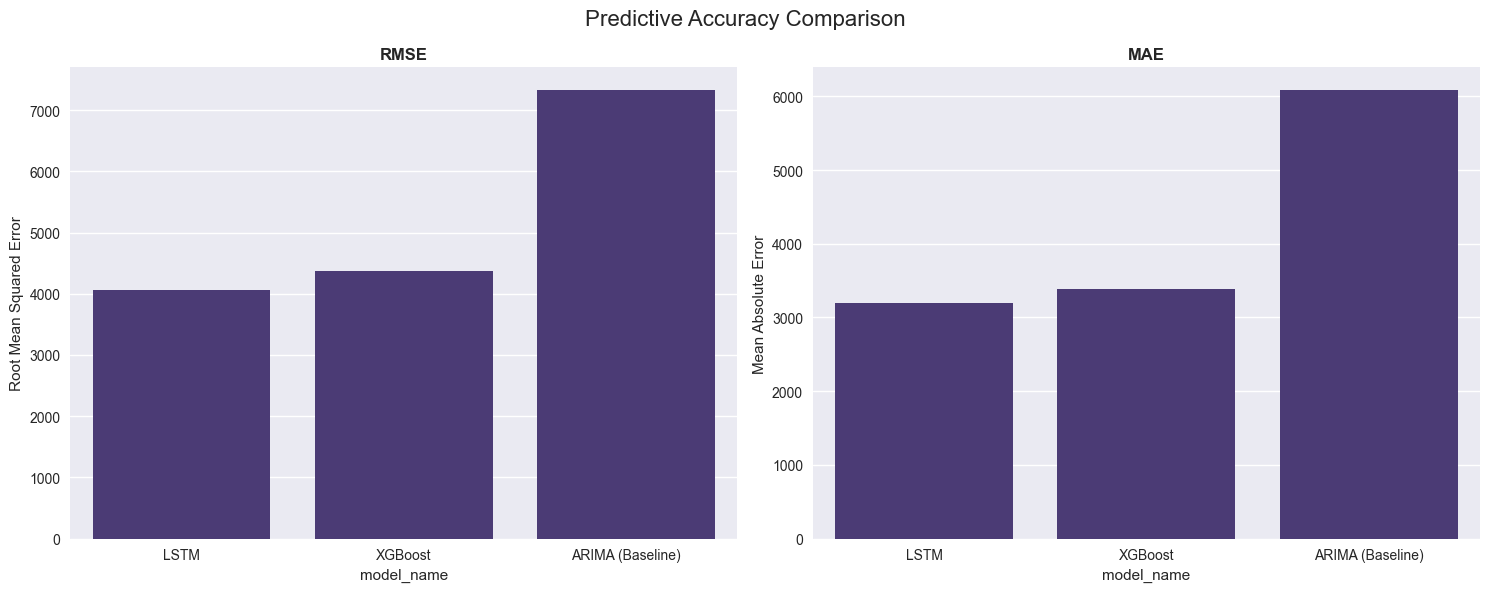

In [4]:
if not df_comparison.empty:
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # RMSE Comparison
    sns.barplot(x='model_name', y='rmse', data=df_comparison, ax=ax[0])
    ax[0].set_title('RMSE', fontweight='bold')
    ax[0].set_ylabel('Root Mean Squared Error')

    # MAE Comparison
    sns.barplot(x='model_name', y='mae', data=df_comparison, ax=ax[1])
    ax[1].set_title('MAE', fontweight='bold')
    ax[1].set_ylabel('Mean Absolute Error')

    plt.suptitle('Predictive Accuracy Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

## Predictions for Time-Seies Plot

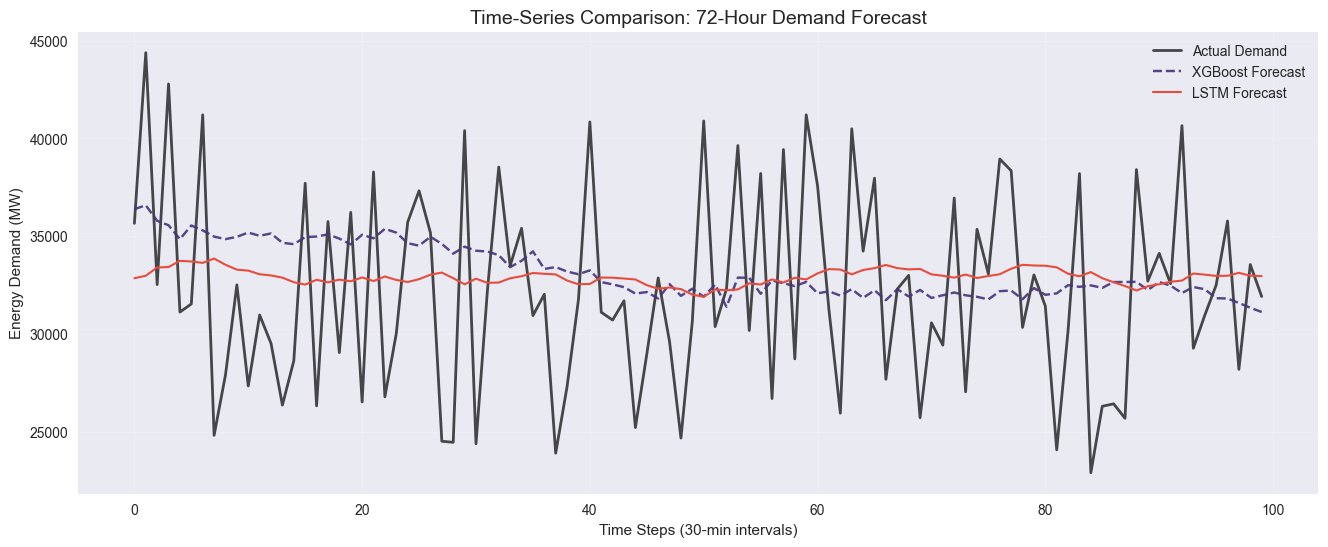

In [5]:
# Load saved arrays for plotting the curves
try:
    actual = np.load(os.path.join(RESULTS_DIR, 'actual_values.npy'))
    xgb_preds = np.load(os.path.join(RESULTS_DIR, 'xgb_preds.npy'))
    lstm_preds = np.load(os.path.join(RESULTS_DIR, 'lstm_preds.npy'))
    
    # We will plot a 3-day window (approx 144 half-hour steps)
    window = 144 

    plt.figure(figsize=(16, 6))
    plt.plot(actual[:window], label='Actual Demand', color='black', linewidth=2, alpha=0.7)
    plt.plot(xgb_preds[:window], label='XGBoost Forecast', linestyle='--', alpha=0.9)
    plt.plot(lstm_preds[:window], label='LSTM Forecast', color='#e74c3c', linewidth=1.5)

    plt.title('Time-Series Comparison: 72-Hour Demand Forecast', fontsize=14)
    plt.xlabel('Time Steps (30-min intervals)')
    plt.ylabel('Energy Demand (MW)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

except FileNotFoundError as e:
    print(f"Visualisation Error: {e}")
    print("Action: Ensure you saved the .npy files in the training notebooks.")